# E-Commerce Customer Segmentation System

##### Aim : To find meaningful clusters to segregate high-value customers from normal customers, and to shift the marketing wrt clusters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df.shape

(2240, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

### Data Preprocessing

#### 1. Handle Missing Data

In [12]:
from sklearn.impute import SimpleImputer
impute = SimpleImputer(strategy="median")    
df[["Income"]] = impute.fit_transform(df[["Income"]])

# df["Income"] = df["Income"].fillna(df["Income"].median())

In [13]:
df.head(12)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,0,42,14,2,6,4,10,6,0,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,50,49,27,4,7,3,7,6,0,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,3,1,23,2,4,0,4,8,0,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,3,3,2,1,3,0,2,9,0,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,1,1,13,1,1,0,0,20,0,0


#### 2. Feature Engineering

In [15]:
# Year_Birth ---> Age
df["Age"] = 2026 - df["Year_Birth"]

In [22]:
# Dt_Customer ---> Customer_Joining_Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)   # dmy format ---> ymd format
reference_date = df["Dt_Customer"].max()
print(reference_date)       # max is determined by year --> month --> date (sorting)
df["Customer_Joining_Days"] = (reference_date - df["Dt_Customer"]).dt.days       # to remove 'days' from dataset

2014-06-29 00:00:00


In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Joining_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


We are told to find clusters based on customers and not on products, i.e., not which product most of the customers take, but which customers are bound to purchase more

In [24]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Joining_Days'],
      dtype='object')

In [25]:
# Total_Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [26]:
# Total_Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [29]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate", "PhD" : "Postgraduate"
})

In [31]:
# Marital_Status ----> Living_With
df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner", "Together" : "Partner", 
    "Single" : "Alone", "Divorced" : "Alone", "Widow" : "Alone", "Absurd": "Alone", "YOLO" : "Alone"
})

In [32]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Joining_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [39]:
# Dropping unnecessary columns
cols_drop = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", 
             "MntWines", "MntFruits", "MntMeatProducts","MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df_cleaned = df.drop(columns = cols_drop)

In [40]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Joining_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [42]:
df_cleaned.shape

(2240, 15)

#### 3. Outlier Detection and Removal

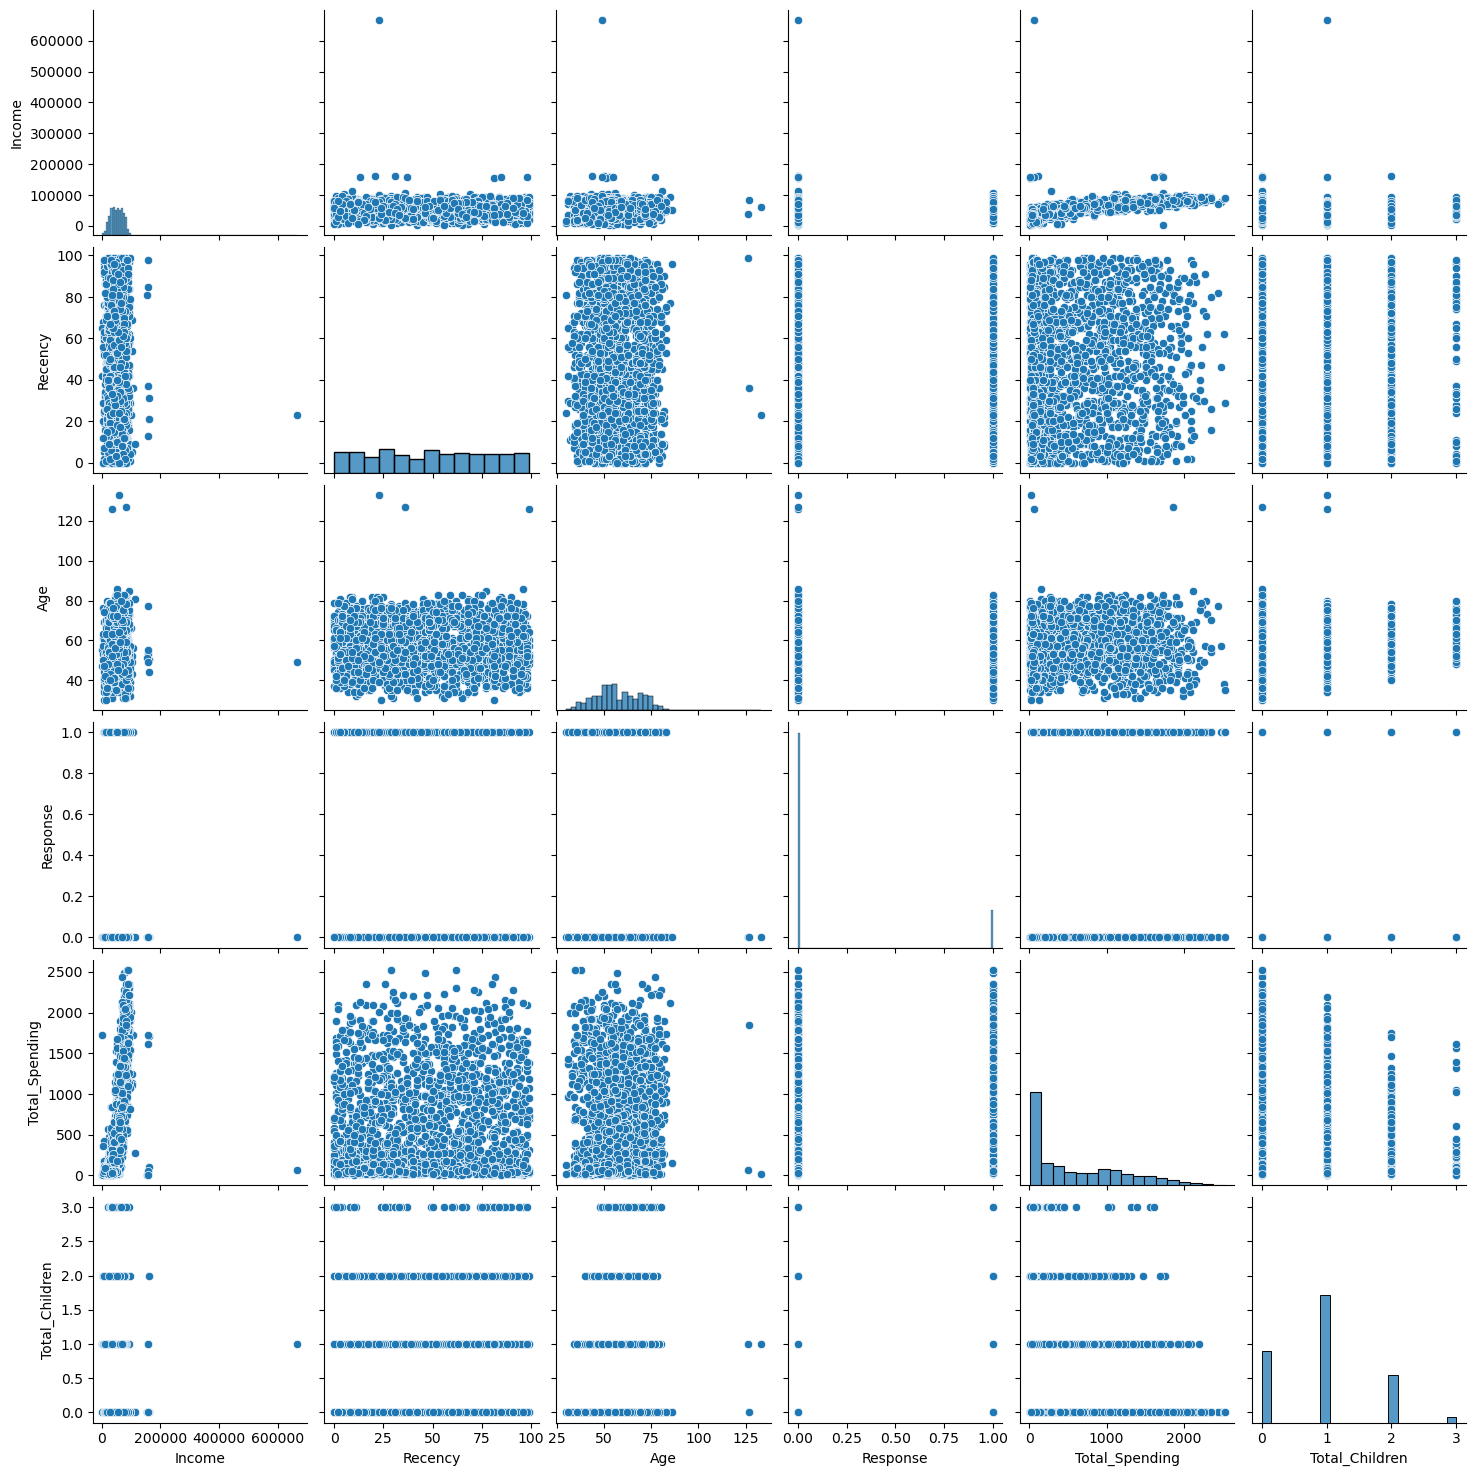

In [45]:
cols = ["Income", "Recency", "Age", "Response", "Total_Spending", "Total_Children"]   # Mainly analyze numerical columns for outliers
# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [46]:
# Remove Outlier
print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Income"] < 600_000]
df_cleaned = df_cleaned[df_cleaned["Age"] < 100]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


#### 4. Correlation Heatmap

In [48]:
corr = df_cleaned.corr(numeric_only=True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Joining_Days,Total_Spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


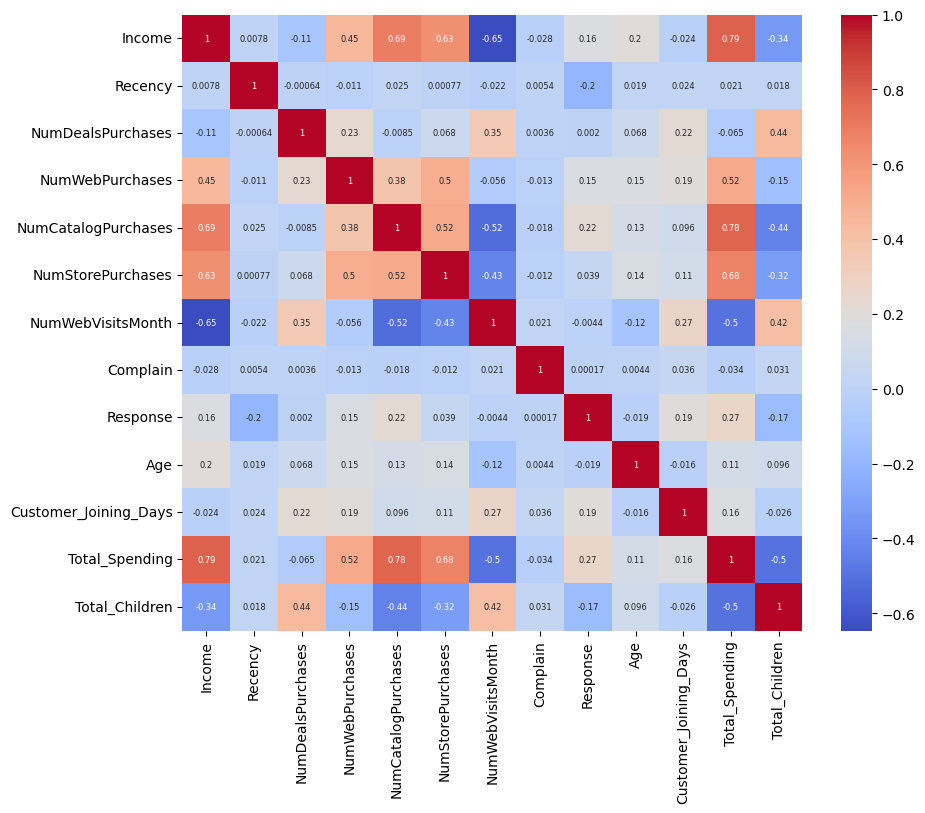

In [58]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, annot_kws={"size":6}, cmap="coolwarm")
plt.show()

#### 5. Feature Encoding

In [69]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()               # drop = "first" in OHE leads to loss of data in clustering. So only in supervised learning, drop = "first" should be done
cat_col = ["Education", "Living_With"]
enc_col = ohe.fit_transform(df_cleaned[cat_col])

In [70]:
enc_df = pd.DataFrame(enc_col.toarray(), columns=ohe.get_feature_names_out(cat_col), index=df_cleaned.index)

.toarray is for keeping sparse matrix and converting it into 2D dense array

In [73]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [74]:
final_df = pd.concat([df_cleaned.drop(columns = cat_col), enc_df], axis=1)

In [75]:
final_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Joining_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [77]:
final_df.shape

(2236, 18)

#### 6. Feature Scaling

In [80]:
X = final_df

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [84]:
X_scaled.shape

(2236, 18)

#### 7. Data Visualization --> PCA

In [88]:
# PCA to reduce dimension in order to visualize easily
from sklearn.decomposition import PCA
pca = PCA(n_components=3)   # 3D Visualization
X_pca = pca.fit_transform(X_scaled)

In [89]:
print(pca.explained_variance_ratio_)

[0.23163158 0.11385454 0.10405815]


23% data captured by PC1, 11% data captured by PC2, 10% data captured by PC3

Text(0.5, 0.92, '3d projection')

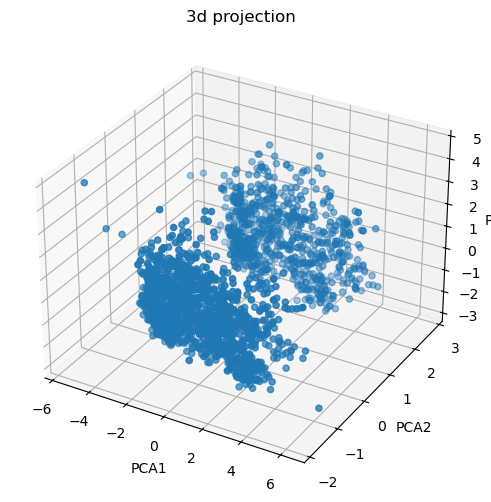

In [90]:
# plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

## Clustering


In [101]:
pca2 = PCA(n_components=0.95)           # to keep 95% of variance/data while making clustering predictions
X_pca2 = pca2.fit_transform(X_scaled)

#### 1. Choose K value

In [106]:
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

In [107]:
# Elbow Method
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [108]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

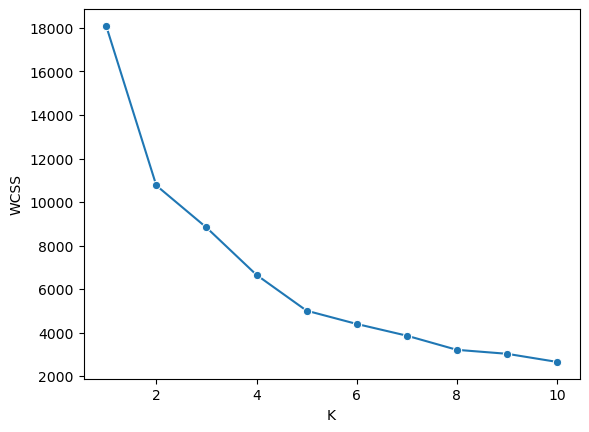

In [110]:
# plot
sns.lineplot(x=range(1, 11), y=wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

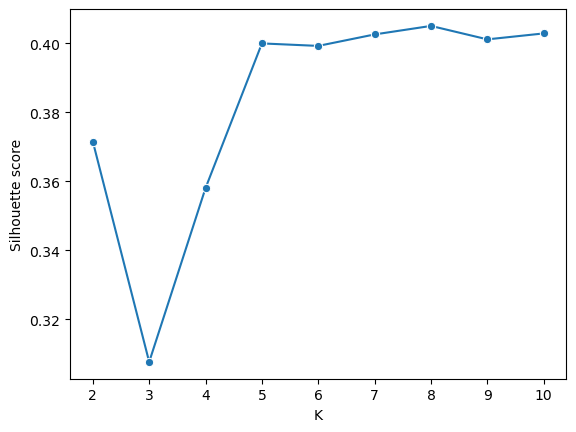

In [115]:
# Silhouette Method
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
sns.lineplot(x=range(2, 11), y=scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Clearly, k is coming different in Silhouette Score and Elbow Method. So we need to take K value by balancing both.

Text(0, 0.5, 'SS')

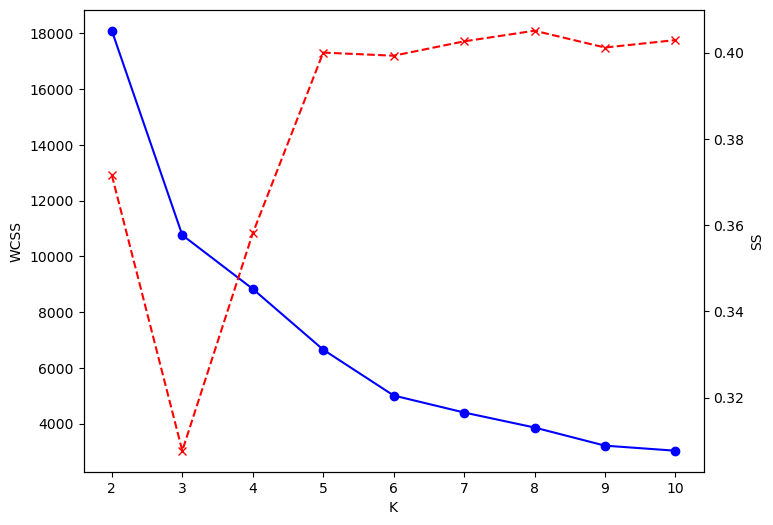

In [117]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()    # create same x-axis label for ax2 as it was set in ax1
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

Both the curve cut each other at around k=4. So it is the best value of k

#### 2. Perform Clustering Algo

In [118]:
# KMeans
k_means = KMeans(n_clusters=4, random_state=42)
labels_kmeans = k_means.fit_predict(X_pca)

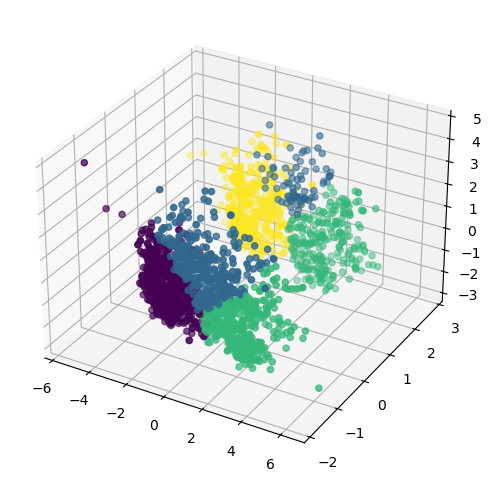

In [120]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [121]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

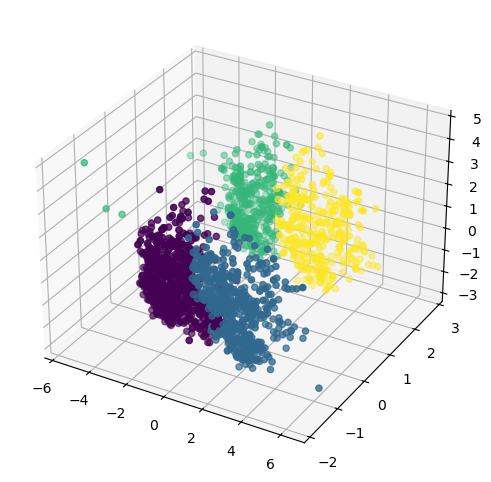

In [122]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

In [131]:
# DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.8, min_samples = 5)
labels_db = dbscan.fit_predict(X_pca)

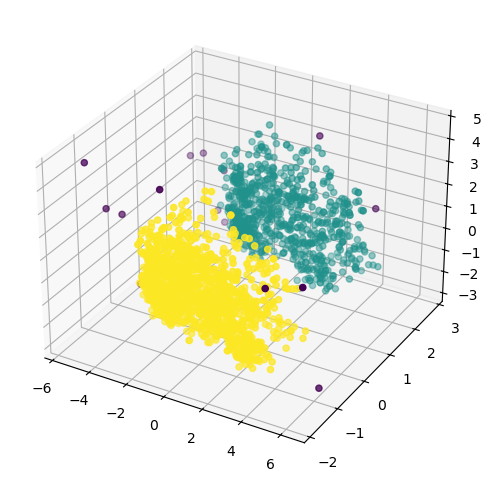

In [132]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_db)

In [133]:
print(labels_db)

[0 0 1 ... 0 1 1]


In [140]:
print(np.sum(labels==9))    # Clearly there are around 10 clusters 

242


DBSCAN has 10 clusters which is too much for an e-commerce company. We will keep max 5 to 6 clusters. Also we know that other 2 clustering algo have only 4 clusters because we specified it. Hence,
##### best model --> Agglomerative Clustering

## Characterization of Clusters

In [147]:
X["clusters"] = labels_agg

In [148]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Joining_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

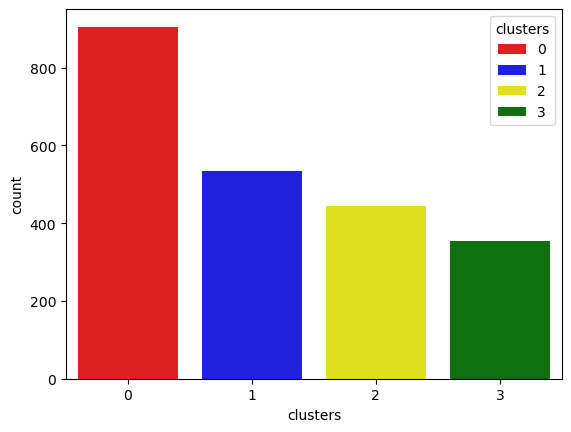

In [149]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["clusters"], palette=pal, hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

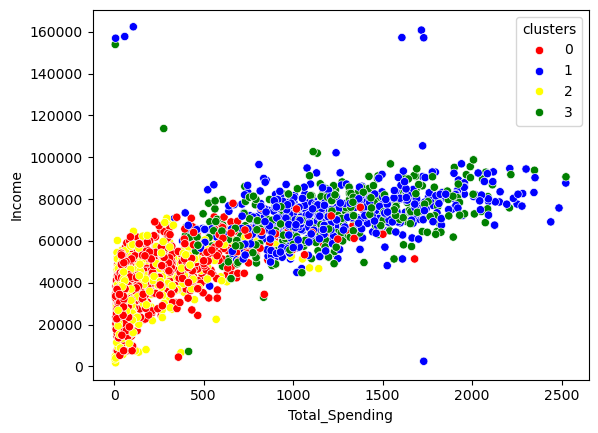

In [150]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["clusters"], palette=pal)

In [152]:
# Cluster Summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Joining_Days  Total_Spending  \
cl

#### Conclusions: